# ECG classification dataset

The data for this notebook can be obtained from [Kaggle ECG hearbeat classification dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat). Place the csv files in a data_directory and change the location of DATA_DIR in the next cell to reference it.


In [ ]:
from pathlib import Path
import os
import random

import torch
import numpy as np
import pandas as pd
import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torch.optim import lr_scheduler

import pytorch_lightning as 

# Reset to your data directory
DATA_DIR = "~/external/ml_data/kaggle_datasets/ecg_heartbeat_classification"

Set random number seed:

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

# Use Tensor Cores on Ampere+ GPUs (e.g. RTX 3000/4000 series) for faster matmuls
torch.set_float32_matmul_precision("high")

pl.seed_everything(SEED, workers=True)

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(True)

Seed set to 42


## Data inspection and loading

Let's look at some data.

In [ ]:
data_dir = Path(DATA_DIR).expanduser()
train_data_path = data_dir / "mitbih_train.csv"
test_data_path = data_dir / "mitbih_test.csv"

Read the train dataframe with all columns np.float32 except the last one which is categorical integers using np.uint8. 

In [4]:
td = pd.read_csv(train_data_path)
n_cols = td.shape[1]
dtype_map = {i: np.float32 for i in range(n_cols - 1)}
dtype_map[n_cols - 1] = np.uint8
td = pd.read_csv(train_data_path, dtype=dtype_map)

In [5]:
td.iloc[:, -1].unique()

array([0, 1, 2, 3, 4], dtype=uint8)

<Axes: >

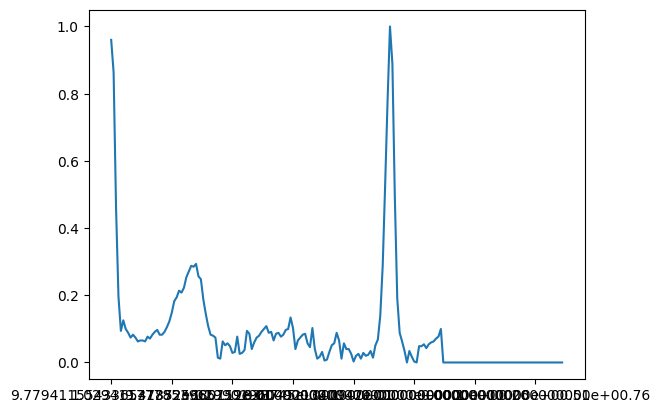

In [6]:
td.iloc[0, :-1].plot()

From inspection, the test data is in the same format as the train data.

In [7]:
test_data = pd.read_csv(test_data_path, dtype=dtype_map)
test_data.iloc[:, -1].unique()

array([0, 1, 2, 3, 4], dtype=uint8)

### Pytorch data sets

In [8]:
class ECGDataset(Dataset):
    VAL_TO_CLASS = {
        0: "N",
        1: "S",
        2: "V",
        3: "F",
        4: "Q",
    }

    def __init__(self, data: pd.DataFrame, transform=None):
        td = pd.read_csv(train_data_path, nrows=1)
        n_cols = td.shape[1]
        dtype_map = {i: np.float32 for i in range(n_cols - 1)}
        dtype_map[n_cols - 1] = np.uint8
        self.df = pd.read_csv(train_data_path, dtype=dtype_map)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        signal = row.iloc[:-1].to_numpy().astype(np.float32)
        label = int(row.iloc[-1])
        if self.transform:
            signal = self.transform(signal)
        else:
            signal = torch.from_numpy(signal)
        return signal, torch.tensor(label, dtype=torch.long)


Create the main train dataset, and break down into train and validation subsets using random_split.

Make sure to set a random seed before doing this so we're repeatable.

In [9]:
full_ds = ECGDataset(td)

train_ds, val_ds = random_split(full_ds, [0.8, 0.2], generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=8)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=8)
test_dl = DataLoader(ECGDataset(test_data), batch_size=64, shuffle=False, num_workers=8)

In [10]:
def inspect_dataloader(dl):
    print("DataLoader:", dl)
    print("dataset type:", type(dl.dataset).__name__)
    print("dataset size:", len(dl.dataset))
    print("num batches:", len(dl))              # if dataset has __len__
    print("batch_size:", dl.batch_size)
    print("num_workers:", dl.num_workers)
    print("pin_memory:", dl.pin_memory)
    print("drop_last:", dl.drop_last)
    print("sampler:", type(dl.sampler).__name__)  # RandomSampler => shuffled

    x, y = next(iter(dl))
    print("x type:", type(x), "x shape:", getattr(x, "shape", None), "x dtype:", getattr(x, "dtype", None))
    print("y type:", type(y), "y shape:", getattr(y, "shape", None), "y dtype:", getattr(y, "dtype", None))



In [11]:
inspect_dataloader(train_dl)

DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7acbcae4d520>
dataset type: Subset
dataset size: 70043
num batches: 1095
batch_size: 64
num_workers: 8
pin_memory: False
drop_last: False
sampler: RandomSampler
x type: <class 'torch.Tensor'> x shape: torch.Size([64, 187]) x dtype: torch.float32
y type: <class 'torch.Tensor'> y shape: torch.Size([64]) y dtype: torch.int64


In [12]:
inspect_dataloader(val_dl)

DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7ac964656780>
dataset type: Subset
dataset size: 17510
num batches: 274
batch_size: 64
num_workers: 8
pin_memory: False
drop_last: False
sampler: SequentialSampler
x type: <class 'torch.Tensor'> x shape: torch.Size([64, 187]) x dtype: torch.float32
y type: <class 'torch.Tensor'> y shape: torch.Size([64]) y dtype: torch.int64


In [13]:
inspect_dataloader(test_dl)

DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7ac96487c470>
dataset type: ECGDataset
dataset size: 87553
num batches: 1369
batch_size: 64
num_workers: 8
pin_memory: False
drop_last: False
sampler: SequentialSampler
x type: <class 'torch.Tensor'> x shape: torch.Size([64, 187]) x dtype: torch.float32
y type: <class 'torch.Tensor'> y shape: torch.Size([64]) y dtype: torch.int64


## Build the model from the paper

Actually, we adapted from [github for the paper](https://github.com/sajiddeboss/ECG-HeartBeat-Classification/blob/main/Model.ipynb)



In [ ]:
import torch.nn as nn
import torch.nn.functional as F



class EcgClassifier(nn.Module):
    def __init__(self):
        super(EcgClassifier, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5)
        self.pool = nn.MaxPool1d(kernel_size=3)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(256, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 5)
        
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        # Input shape: (batch, 187) -> add channel dim -> (batch, 1, 187)
        x = x.unsqueeze(1)
        
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.global_avg_pool(x)
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1)  # Flatten
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        #x = self.softmax(x) - using cross-entropy loss which applies softmax internally
        
        return x


Create a lightning module to encapsulate the training and setup of the model.

Pass class weights to CrossEntropyLoss to handle the class imbalance in the dataset.


In [15]:
# Compute inverse-frequency class weights from the training subset
train_labels = np.array([full_ds[i][1].item() for i in train_ds.indices])
class_counts = np.bincount(train_labels, minlength=5)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalise so weights sum to num_classes

print("Class counts:", dict(zip(ECGDataset.VAL_TO_CLASS.values(), class_counts)))
print("Class weights:", dict(zip(ECGDataset.VAL_TO_CLASS.values(), np.round(class_weights, 4))))

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)


Class counts: {'N': np.int64(58054), 'S': np.int64(1743), 'V': np.int64(4618), 'F': np.int64(523), 'Q': np.int64(5105)}
Class weights: {'N': np.float64(0.0295), 'S': np.float64(0.9839), 'V': np.float64(0.3714), 'F': np.float64(3.2792), 'Q': np.float64(0.3359)}


In [16]:
import torchmetrics


class EcgLightningModule(pl.LightningModule):
    def __init__(self, num_classes: int, learning_rate: float = 1e-3, weight_decay: float = 1e-4,
                 class_weights: torch.Tensor = None):
        super(EcgLightningModule, self).__init__()
        self.model = EcgClassifier()
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        # class_weights will be moved to the correct device automatically via register_buffer
        self.register_buffer("class_weights", class_weights)

        # Epoch-averaged history (populated in on_*_epoch_end hooks)
        self.training_step_outputs = {"loss": [], "acc": []}
        self.validation_step_outputs = {"loss": [], "acc": []}

        # torchmetrics accumulate correctly across all batches in an epoch
        self.train_loss = torchmetrics.MeanMetric()
        self.val_loss   = torchmetrics.MeanMetric()
        self.train_acc  = torchmetrics.classification.Accuracy(num_classes=num_classes, task="multiclass")
        self.val_acc    = torchmetrics.classification.Accuracy(num_classes=num_classes, task="multiclass")

    @property
    def loss_fn(self):
        return nn.CrossEntropyLoss(weight=self.class_weights)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.train_loss(loss)
        self.train_acc(logits, y)
        self.log("train_loss", self.train_loss, on_step=True, on_epoch=True,
                 prog_bar=True, logger=True)
        self.log("train_acc",  self.train_acc,  on_step=True, on_epoch=True,
                 prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.val_loss(loss)
        self.val_acc(logits, y)
        self.log("val_loss", self.val_loss, on_step=False, on_epoch=True,
                 prog_bar=True, logger=True)
        self.log("val_acc",  self.val_acc,  on_step=False, on_epoch=True,
                 prog_bar=True, logger=True)
        self.log("lr",  self.optimizers().param_groups[0]['lr'],  on_step=False, on_epoch=True,
                 prog_bar=True, logger=True)        

    def on_train_epoch_end(self):
        metrics = self.trainer.callback_metrics
        self.training_step_outputs["loss"].append(metrics["train_loss_epoch"].item())
        self.training_step_outputs["acc"].append(metrics["train_acc_epoch"].item())

    def on_validation_epoch_end(self):
        metrics = self.trainer.callback_metrics
        if "val_loss" in metrics:
            self.validation_step_outputs["loss"].append(metrics["val_loss"].item())
            self.validation_step_outputs["acc"].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            params=self.model.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",       # minimise val_loss
            factor=0.5,       # 1/5 LR on plateau
            patience=2,       # wait 5 epochs before reducing
            min_lr=1e-6,      # don't reduce below 1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",   # required for ReduceLROnPlateau
                "interval": "epoch",
                "frequency": 1,
            },
        }

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        logits = self(x)
        return logits.argmax(dim=1)


FIXME: I want to optimize using the validation loss minimised. Check how to do that.

In [17]:
from pytorch_lightning.callbacks import LearningRateMonitor, TQDMProgressBar, EarlyStopping, ModelCheckpoint


class LrProgressBar(TQDMProgressBar):
    """Show LR in scientific notation in the progress bar."""
    def get_metrics(self, trainer, model):
        items = super().get_metrics(trainer, model)
        for key in list(items):
            if "lr" in key.lower():
                items[key] = f"{float(items[key]):.2e}"
        return items


EPOCHS = 100
log_every_n_steps = 10

early_stop_cb = EarlyStopping(
    monitor="val_loss",   # metric to watch
    patience=10,          # stop after 10 epochs with no improvement
    mode="min",           # lower is better
    verbose=True,
)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="ecg-best-{epoch:02d}-{val_loss:.4f}",
    verbose=True,
)

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    log_every_n_steps=log_every_n_steps,
    gradient_clip_val=1.0,
    accelerator="gpu",
    callbacks=[
        early_stop_cb,
        checkpoint_cb,
        LearningRateMonitor(logging_interval="epoch"),
        LrProgressBar(),
    ],
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/michaelw/.pyenv/versions/py_3_12_8/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [18]:
lightning_module = EcgLightningModule(num_classes=5, learning_rate=1e-3, weight_decay=5e-5,
                                      class_weights=class_weights_tensor)
trainer.fit(lightning_module, train_dl, val_dl)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ EcgClassifier      │  667 K │ train │     0 │
│ 1 │ train_loss │ MeanMetric         │      0 │ train │     0 │
│ 2 │ val_loss   │ MeanMetric         │      0 │ train │     0 │
│ 3 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 667 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 667 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Epoch 31, global step 35040: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 32, global step 36135: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.394. Signaling Trainer to stop.
Epoch 33, global step 37230: 'val_loss' was not in top 1


In [19]:
print(f"Train: Final Loss == {lightning_module.training_step_outputs['loss'][-1]:.4f}, Final Acc == {lightning_module.training_step_outputs['acc'][-1]:.4f}")

Train: Final Loss == 0.2668, Final Acc == 0.9624


In [20]:
print(f"Val: Final Loss == {lightning_module.validation_step_outputs['loss'][-1]:.4f}, Final Acc == {lightning_module.validation_step_outputs['acc'][-1]:.4f}")

Val: Final Loss == 0.4817, Final Acc == 0.9661


In [21]:
t = lightning_module.training_step_outputs
v = lightning_module.validation_step_outputs
len(t["loss"]), len(t["acc"]), len(v["loss"]), len(v["acc"])

(34, 34, 35, 35)

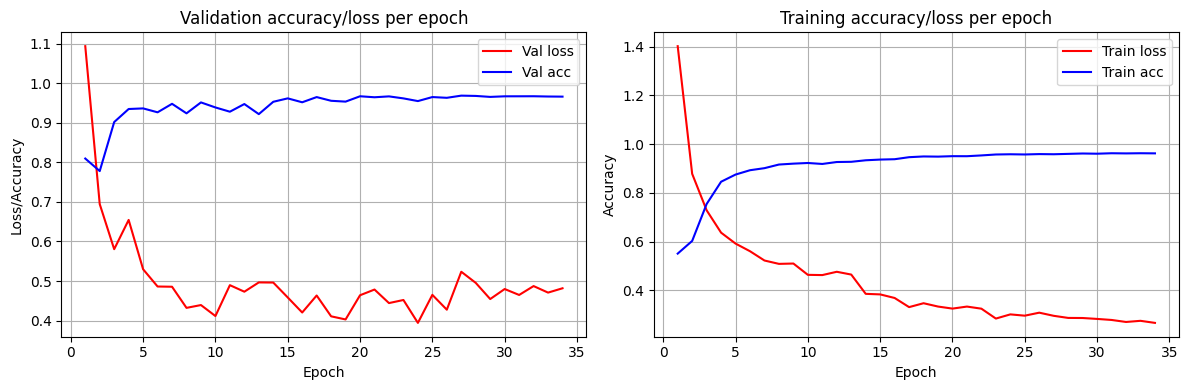

In [23]:
def plot_training_history(module):
    train = module.training_step_outputs
    val = module.validation_step_outputs

    train_loss = train["loss"]
    train_acc  = train["acc"]
    val_loss   = val["loss"][1:]
    val_acc    = val["acc"][1:]
    epochs = range(1, len(train_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, val_loss, label="Val loss", color="red")
    ax1.plot(epochs, val_acc, label="Val acc", color="blue")    
    ax1.set_title("Validation accuracy/loss per epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss/Accuracy")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_loss, label="Train loss", color="red")
    ax2.plot(epochs, train_acc, label="Train acc", color="blue")

    ax2.set_title("Training accuracy/loss per epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(lightning_module)


In [24]:
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, cohen_kappa_score

def print_pred_truth_comparison(truth_array, pred_array):
    class_names = [ECGDataset.VAL_TO_CLASS[i] for i in sorted(ECGDataset.VAL_TO_CLASS)]

    overall_acc      = accuracy_score(truth_array, pred_array)
    balanced_acc     = balanced_accuracy_score(truth_array, pred_array)
    kappa            = cohen_kappa_score(truth_array, pred_array)
    n_correct        = (truth_array == pred_array).sum()
    n_total          = len(truth_array)
    print(f"Overall accuracy   : {overall_acc:.4f}  ({n_correct:,} / {n_total:,} correct)")
    print(f"Balanced accuracy  : {balanced_acc:.4f}  (accounts for class imbalance)")
    print(f"Cohen's kappa      : {kappa:.4f}  (1=perfect, 0=chance)")
    print()
    print("Per-class report:")
    print(classification_report(truth_array, pred_array, target_names=class_names, digits=4))

    # Per-class accuracy breakdown
    print("Per-class accuracy:")
    for i, name in enumerate(class_names):
        mask = truth_array == i
        cls_acc = (pred_array[mask] == i).mean() if mask.sum() > 0 else float("nan")
        print(f"  {name}: {cls_acc:.4f}  (n={mask.sum():,})")


### Confusion matrix

We want to visualize confusion matrices for train, val and test sets.



In [25]:
# Use a non-shuffled dataloader so truth and preds are in the same order
train_eval_dl = DataLoader(train_ds, batch_size=256, shuffle=False, num_workers=8)

# Ground Truth
train_truth = np.concatenate([y.numpy() for _, y in train_eval_dl])

# Predictions — load best checkpoint weights automatically
train_preds = trainer.predict(lightning_module, train_eval_dl, ckpt_path="best")
train_preds = torch.cat(train_preds).cpu().numpy().astype(np.uint8)

train_preds.shape, train_truth.shape


Restoring states from the checkpoint path at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

((70043,), (70043,))

In [26]:
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, cohen_kappa_score

def print_pred_truth_comparison(truth_array, pred_array):
    class_names = [ECGDataset.VAL_TO_CLASS[i] for i in sorted(ECGDataset.VAL_TO_CLASS)]

    overall_acc      = accuracy_score(truth_array, pred_array)
    balanced_acc     = balanced_accuracy_score(truth_array, pred_array)
    kappa            = cohen_kappa_score(truth_array, pred_array)
    n_correct        = (truth_array == pred_array).sum()
    n_total          = len(truth_array)
    print(f"Overall accuracy   : {overall_acc:.4f}  ({n_correct:,} / {n_total:,} correct)")
    print(f"Balanced accuracy  : {balanced_acc:.4f}  (accounts for class imbalance)")
    print(f"Cohen's kappa      : {kappa:.4f}  (1=perfect, 0=chance)")
    print()
    print("Per-class report:")
    print(classification_report(truth_array, pred_array, target_names=class_names, digits=4))

    # Per-class accuracy breakdown
    print("Per-class accuracy:")
    for i, name in enumerate(class_names):
        mask = truth_array == i
        cls_acc = (pred_array[mask] == i).mean() if mask.sum() > 0 else float("nan")
        print(f"  {name}: {cls_acc:.4f}  (n={mask.sum():,})")


In [27]:
print_pred_truth_comparison(train_truth, train_preds)

Overall accuracy   : 0.9593  (67,193 / 70,043 correct)
Balanced accuracy  : 0.9329  (accounts for class imbalance)
Cohen's kappa      : 0.8748  (1=perfect, 0=chance)

Per-class report:
              precision    recall  f1-score   support

           N     0.9931    0.9593    0.9759     58054
           S     0.4681    0.8468    0.6029      1743
           V     0.9151    0.9710    0.9422      4618
           F     0.7389    0.8929    0.8087       523
           Q     0.9615    0.9943    0.9777      5105

    accuracy                         0.9593     70043
   macro avg     0.8154    0.9329    0.8615     70043
weighted avg     0.9707    0.9593    0.9633     70043

Per-class accuracy:
  N: 0.9593  (n=58,054)
  S: 0.8468  (n=1,743)
  V: 0.9710  (n=4,618)
  F: 0.8929  (n=523)
  Q: 0.9943  (n=5,105)


Do:
- confusion matrix
- against test data loader

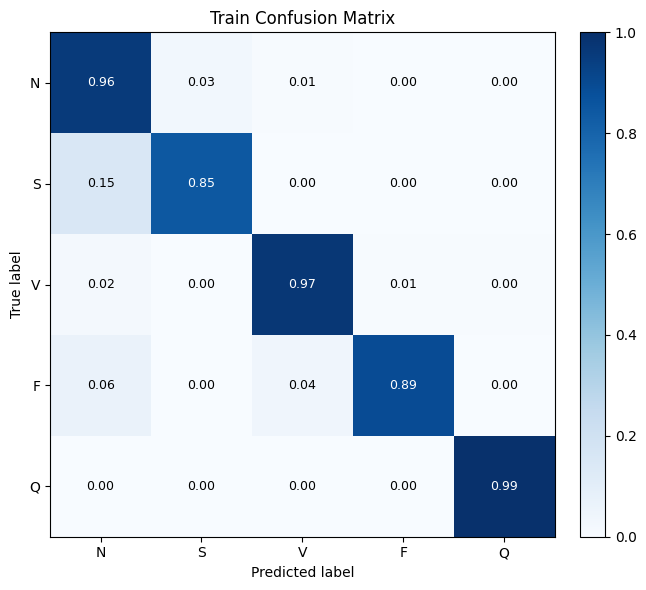

In [28]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(truth, preds, title="Confusion Matrix", normalize=True):
    class_names = [ECGDataset.VAL_TO_CLASS[i] for i in sorted(ECGDataset.VAL_TO_CLASS)]
    cm = confusion_matrix(truth, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

    display = cm_norm if normalize else cm.astype(float)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(display, interpolation="nearest", cmap="Blues",
                   vmin=0, vmax=1 if normalize else None)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    thresh = display.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = f"{cm_norm[i, j]:.2f}" if normalize else f"{cm[i, j]:,}"
            ax.text(j, i, value,
                    ha="center", va="center",
                    color="white" if display[i, j] > thresh else "black",
                    fontsize=9)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(train_truth, train_preds, title="Train Confusion Matrix", normalize=True)


### Confusion matrix for validation dataset

In [29]:
# Ground Truth
val_truth = np.concatenate([y.numpy() for _, y in val_dl])

# Predictions — load best checkpoint weights automatically
val_preds = trainer.predict(lightning_module, val_dl, ckpt_path="best")
val_preds = torch.cat(val_preds).cpu().numpy().astype(np.uint8)
val_preds.shape, val_truth.shape

Restoring states from the checkpoint path at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

((17510,), (17510,))

In [30]:
print_pred_truth_comparison(val_truth, val_preds)

Overall accuracy   : 0.9548  (16,719 / 17,510 correct)
Balanced accuracy  : 0.8985  (accounts for class imbalance)
Cohen's kappa      : 0.8639  (1=perfect, 0=chance)

Per-class report:
              precision    recall  f1-score   support

           N     0.9899    0.9581    0.9737     14416
           S     0.4685    0.7896    0.5881       480
           V     0.9048    0.9581    0.9307      1170
           F     0.7121    0.7966    0.7520       118
           Q     0.9535    0.9902    0.9715      1326

    accuracy                         0.9548     17510
   macro avg     0.8058    0.8985    0.8432     17510
weighted avg     0.9653    0.9548    0.9586     17510

Per-class accuracy:
  N: 0.9581  (n=14,416)
  S: 0.7896  (n=480)
  V: 0.9581  (n=1,170)
  F: 0.7966  (n=118)
  Q: 0.9902  (n=1,326)


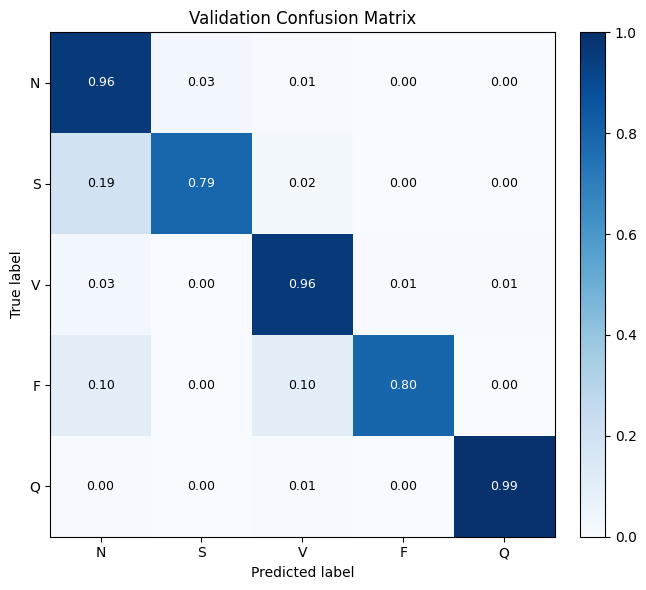

In [31]:
plot_confusion_matrix(val_truth, val_preds, title="Validation Confusion Matrix", normalize=True)

### Confusion Matrix for test set

In [32]:
# Ground Truth
test_truth = np.concatenate([y.numpy() for _, y in test_dl])

# Predictions — load best checkpoint weights automatically
test_preds = trainer.predict(lightning_module, test_dl, ckpt_path="best")
test_preds = torch.cat(test_preds).cpu().numpy().astype(np.uint8)
test_preds.shape, test_truth.shape

Restoring states from the checkpoint path at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/michaelw/prog/kaggle/ecg/lightning_logs/version_1/checkpoints/ecg-best-epoch=23-val_loss=0.3942.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

((87553,), (87553,))

In [33]:
print_pred_truth_comparison(test_truth, test_preds)

Overall accuracy   : 0.9584  (83,913 / 87,553 correct)
Balanced accuracy  : 0.9261  (accounts for class imbalance)
Cohen's kappa      : 0.8726  (1=perfect, 0=chance)

Per-class report:
              precision    recall  f1-score   support

           N     0.9924    0.9591    0.9755     72470
           S     0.4684    0.8345    0.6000      2223
           V     0.9129    0.9682    0.9397      5788
           F     0.7353    0.8752    0.7991       641
           Q     0.9599    0.9935    0.9764      6431

    accuracy                         0.9584     87553
   macro avg     0.8138    0.9261    0.8581     87553
weighted avg     0.9696    0.9584    0.9623     87553

Per-class accuracy:
  N: 0.9591  (n=72,470)
  S: 0.8345  (n=2,223)
  V: 0.9682  (n=5,788)
  F: 0.8752  (n=641)
  Q: 0.9935  (n=6,431)


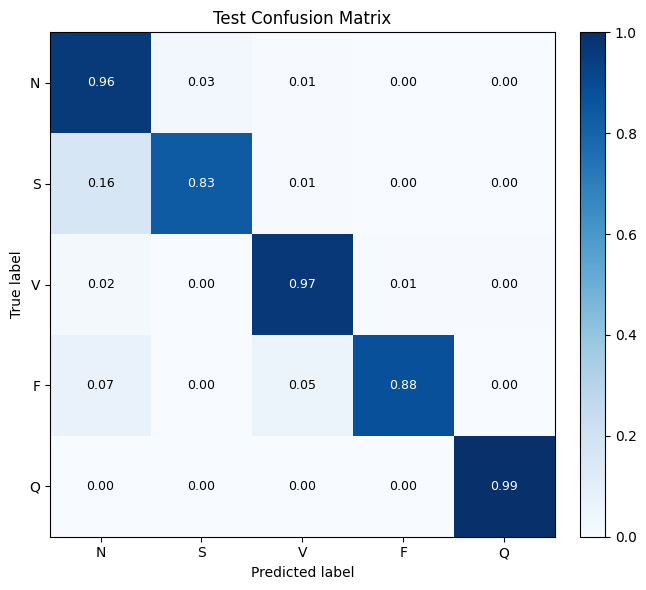

In [34]:
plot_confusion_matrix(test_truth, test_preds, title="Test Confusion Matrix", normalize=True)